# Visualizations on CHAPA Chapter 40B Application Data 2021-2025
Author: Gia Bao (Belinda) Ngo

**Dataset path:** `fa25-team-a/data/CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.3.csv`

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the merged & cleaned Chapter 40B dataset

In [21]:
file_path = "../data/CHAPA_Chapter-40B_Application-Data_2021-2025_merged_v0.3.csv"
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower()
df.head()

,id_number,submission_date,age,disability,chapa_races,census_races,current_residence_town_city,current_residence_state,current_residence_zip,application_source,...,race_cleaned,race_type,race_american_indian_or_alaska_native,race_asian,race_black_or_african_american,race_hispanic_or_latino,race_middle_eastern_or_north_african,race_native_hawaiian_or_pacific_islander,race_other__prefer_not_to_answer,race_white
0,150733,2022-02-08,65,0,White/Non-Minority,White alone,Somerville,MA,NaN,Unknown,...,['White'],Single Race,0,0,0,0,0,0,0,1
1,439181,2022-02-08,59,0,Hispanic/Latino,Unknown,Westford,MA,NaN,Unknown,...,['Hispanic or Latino'],Single Race,0,0,0,1,0,0,0,0
2,697399,2022-02-08,0,0,Black or African American,Black or African American alone,Malden,MA,NaN,Unknown,...,['Black or African American'],Single Race,0,0,1,0,0,0,0,0
3,191565,2022-02-08,0,0,White/Non-Minority,White alone,Haverhill,MA,NaN,Unknown,...,['White'],Single Race,0,0,0,0,0,0,0,1
4,226436,2022-02-08,60,0,White/Non-Minority,White alone,Nashua,NH,NaN,Unknown,...,['White'],Single Race,0,0,0,0,0,0,0,1


## Visualize

### Question 1a: How far from their current homes, do applicants apply for these affordable homeownership opportunities?

### Question 1b: How does the applicant geographic range compare between different demographic groups? (e.g., race, household type, age, marketing source, etc.). Are local applicant demographics similar or different from more distant applicants?

#### Proportion of Unique Applicants by Current Residence State (Excluding MA and Unknown)

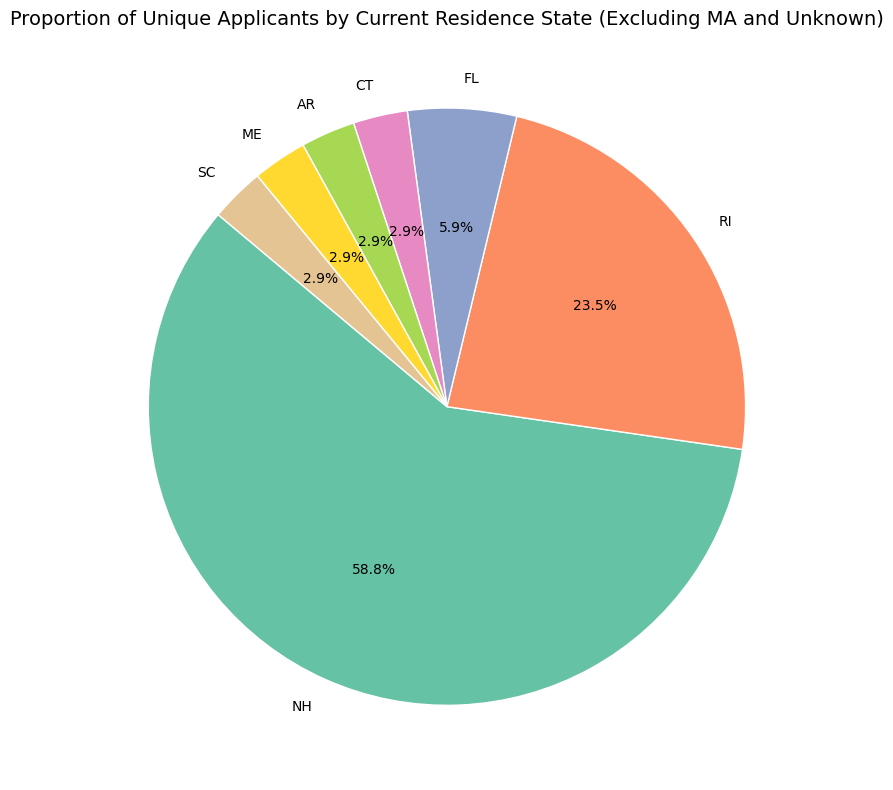

In [8]:
# Filter out MA and Unknown
df_no_ma = df[(df['current_residence_state'] != 'MA') & 
               (df['current_residence_state'] != 'Unknown')]

# Count unique applicants per state
unique_applicants = df_no_ma.groupby('current_residence_state')['id_number'].nunique()
unique_applicants = unique_applicants.sort_values(ascending=False)

# Choose a prettier color palette from seaborn
colors = sns.color_palette("Set2", n_colors=len(unique_applicants))

# Plot pie chart
plt.figure(figsize=(8,8))
plt.pie(
    unique_applicants,
    labels=unique_applicants.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white'}  # adds separation between slices
)
plt.title("Proportion of Unique Applicants by Current Residence State (Excluding MA and Unknown)", fontsize=14)
plt.tight_layout()
plt.show()

### Question 2: To what extent are the applicant demographics driven by CHAPA’s limited property pool (suburban, age-restricted homes) versus applicant choice?

#### Number of Applications by Source

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_83557/3611552726.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='application_source', order=df['application_source'].value_counts().index, palette='Set2')


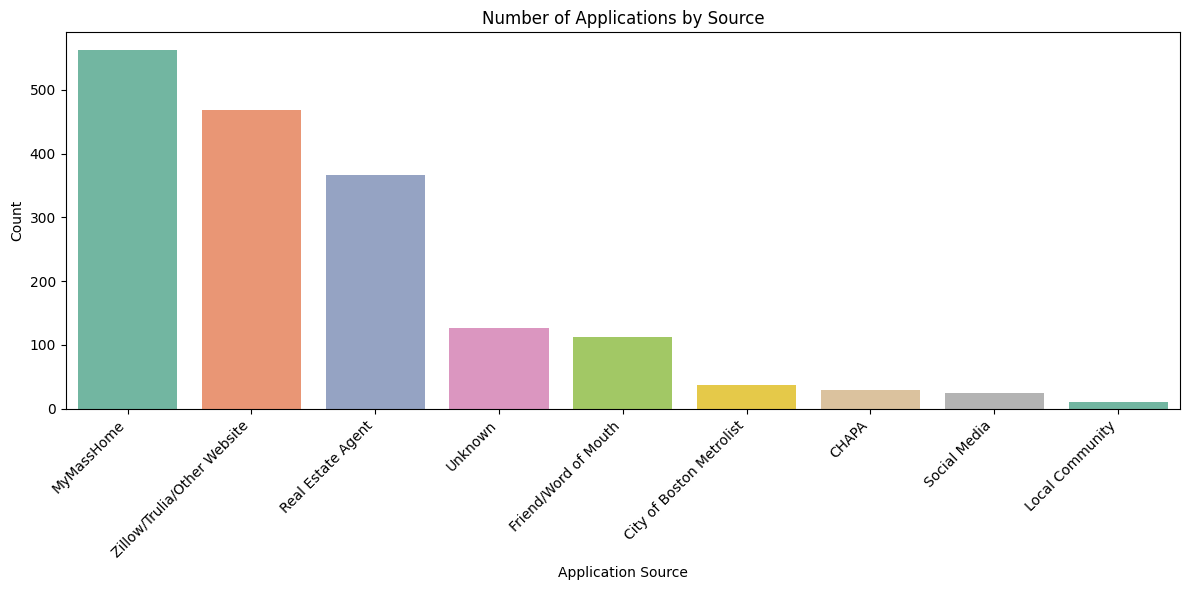

In [12]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='application_source', order=df['application_source'].value_counts().index, palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title("Number of Applications by Source")
plt.ylabel("Count")
plt.xlabel("Application Source")
plt.tight_layout()
plt.show()

#### Marketing source: Repeat vs Non-repeat Applications

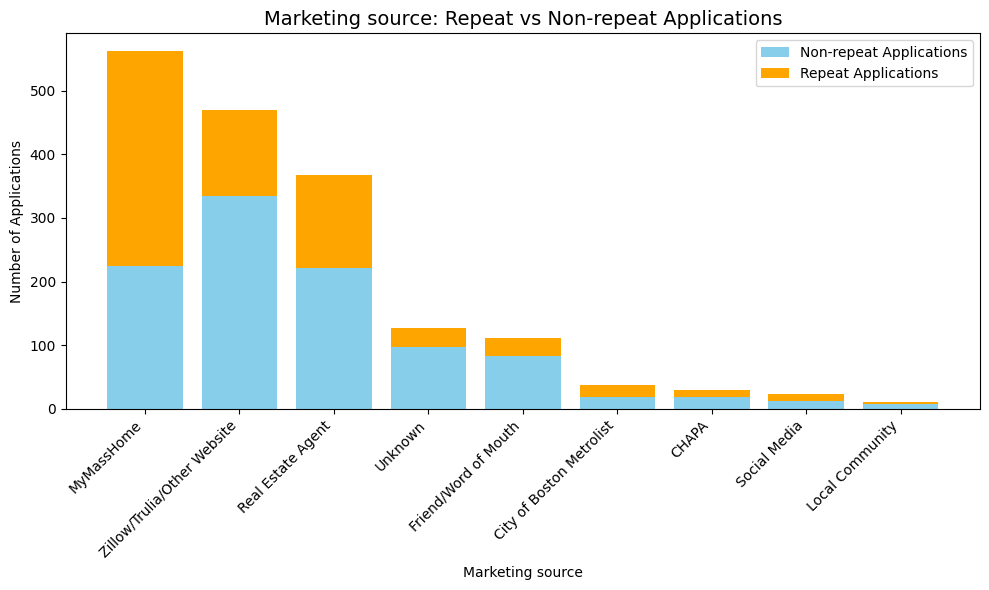

In [13]:
# total applications per town (count all rows)
all_applications = df.groupby('application_source')['id_number'].count()

# identify repeat applicants
app_counts = df['id_number'].value_counts()
df['repeat_applicant'] = df['id_number'].map(app_counts) > 1

# repeat applications per town
repeat_applications = df[df['repeat_applicant']].groupby('application_source')['id_number'].count()

# non-repeat applications
non_repeat_applications = all_applications - repeat_applications

# top 30 towns by total applications
top_30_towns = all_applications.sort_values(ascending=False).head(30).index

# align counts
repeat_applications = repeat_applications.reindex(top_30_towns).fillna(0)
non_repeat_applications = non_repeat_applications.reindex(top_30_towns).fillna(0)

# stacked bar plot
plt.figure(figsize=(10,6))
plt.bar(top_30_towns, non_repeat_applications, color='skyblue', label='Non-repeat Applications')
plt.bar(top_30_towns, repeat_applications, bottom=non_repeat_applications, color='orange', label='Repeat Applications')

plt.title("Marketing source: Repeat vs Non-repeat Applications", fontsize=14)
plt.ylabel("Number of Applications")
plt.xlabel("Marketing source")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# cleanup
df.drop(columns=["repeat_applicant"], inplace=True)

#### Top 30 Towns (out of 54) by Property Count

In [ ]:
col = "property_town_city"
df[col].nunique(), df[col].isnull().sum()

(54, np.int64(0))

/var/folders/jt/_pqrwqgx0fx_x1gscf1xc0km0000gn/T/ipykernel_83557/604493349.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


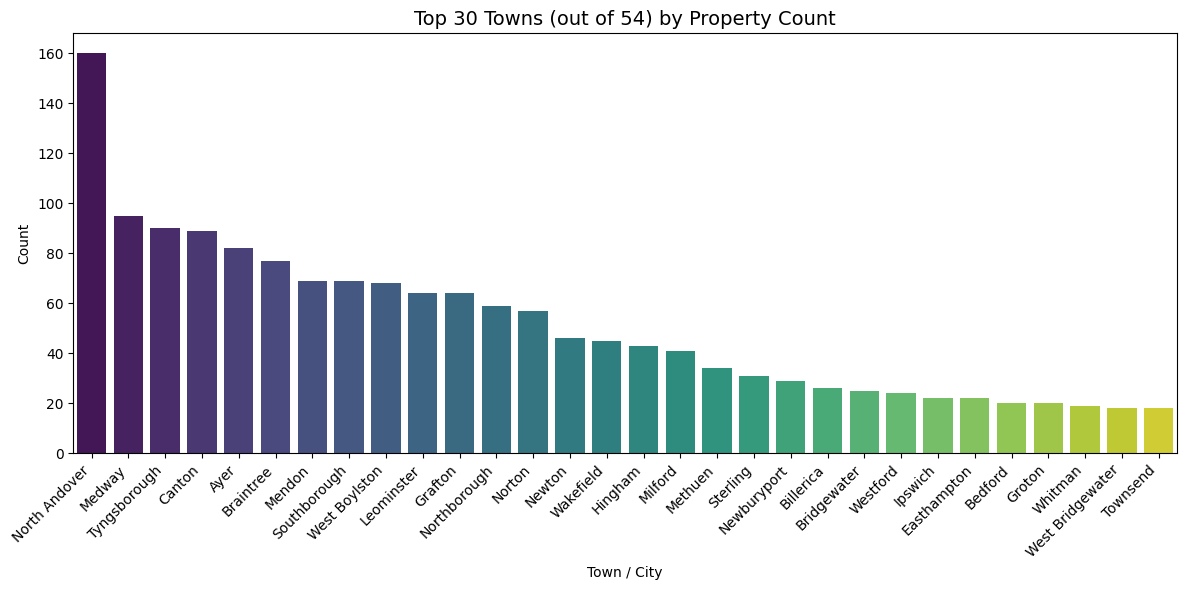

In [ ]:
plt.figure(figsize=(12,6))

top_towns = df['property_town_city'].value_counts().index[:30]

# Filter and define order
sns.countplot(
    data=df[df['property_town_city'].isin(top_towns)],
    x='property_town_city',
    order=top_towns,
    palette='viridis'
)

plt.title("Top 30 Towns (out of 54) by Property Count", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Town / City")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

#### Top 30 Towns: Repeat vs Non-repeat Applications

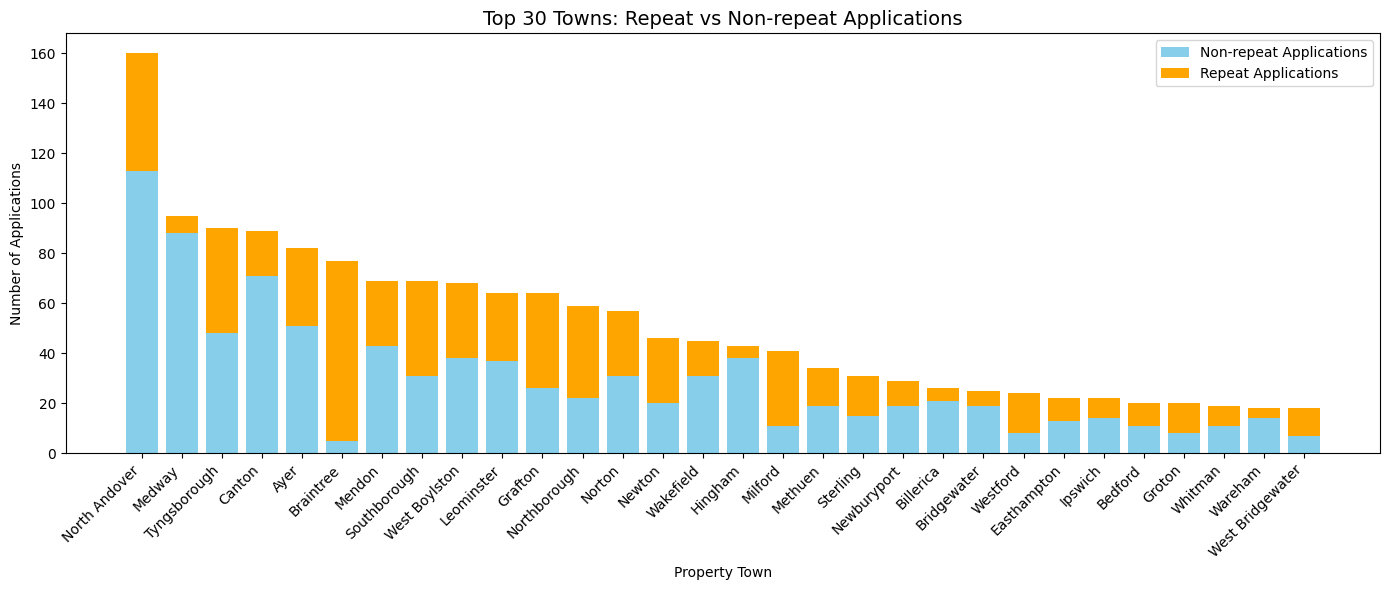

In [ ]:
# total applications per town (count all rows)
all_applications = df.groupby('property_town_city')['id_number'].count()

# identify repeat applicants
app_counts = df['id_number'].value_counts()
df['repeat_applicant'] = df['id_number'].map(app_counts) > 1

# repeat applications per town
repeat_applications = df[df['repeat_applicant']].groupby('property_town_city')['id_number'].count()

# non-repeat applications
non_repeat_applications = all_applications - repeat_applications

# top 30 towns by total applications
top_30_towns = all_applications.sort_values(ascending=False).head(30).index

# align counts
repeat_applications = repeat_applications.reindex(top_30_towns).fillna(0)
non_repeat_applications = non_repeat_applications.reindex(top_30_towns).fillna(0)

# stacked bar plot
plt.figure(figsize=(14,6))
plt.bar(top_30_towns, non_repeat_applications, color='skyblue', label='Non-repeat Applications')
plt.bar(top_30_towns, repeat_applications, bottom=non_repeat_applications, color='orange', label='Repeat Applications')

plt.title("Top 30 Towns: Repeat vs Non-repeat Applications", fontsize=14)
plt.ylabel("Number of Applications")
plt.xlabel("Property Town")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# cleanup
df.drop(columns=["repeat_applicant"], inplace=True)

### Testings

#### Household Assets Distribution (Unique Applicants) (99th percentile)

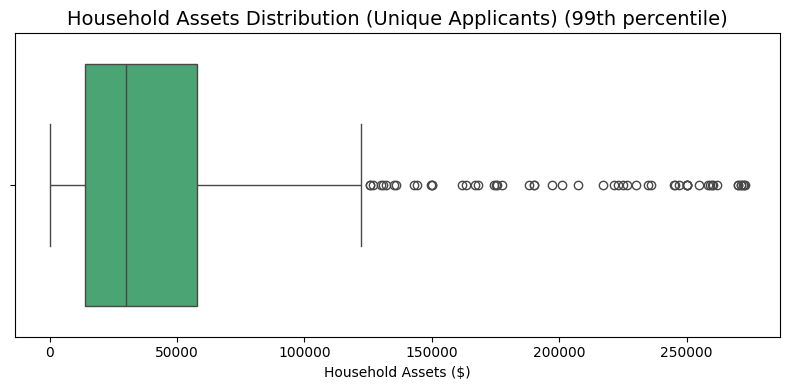

In [15]:
# Remove outlier and duplicates by id_number
df_unique = df[df['hh_assets'] < df['hh_assets'].quantile(0.99)].drop_duplicates(subset="id_number")

# Plot boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_unique["hh_assets"], color="mediumseagreen")
plt.title("Household Assets Distribution (Unique Applicants) (99th percentile)", fontsize=14)
plt.xlabel("Household Assets ($)")
plt.tight_layout()
plt.show()

#### Proportion of First-time Homebuyers by Town

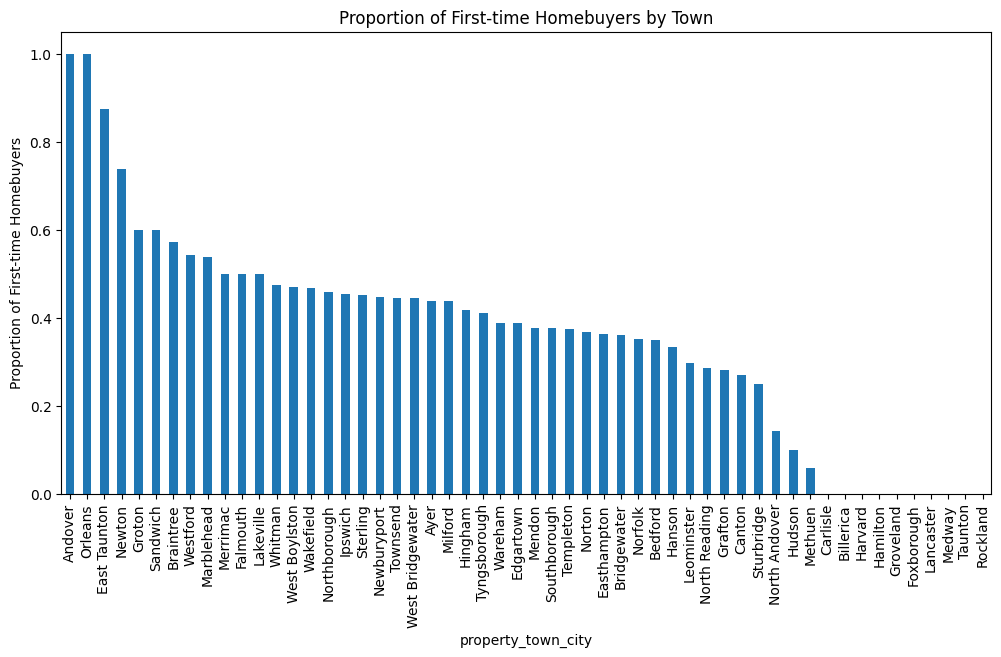

In [ ]:
ftb_rate = df.groupby('property_town_city')['fthb_class'].mean().sort_values(ascending=False)
ftb_rate.plot(kind='bar', figsize=(12,6))
plt.ylabel("Proportion of First-time Homebuyers")
plt.title("Proportion of First-time Homebuyers by Town")
plt.show()